In [1]:
import numpy as np 
import matplotlib.pylab as plt
import pandas as pd

In [2]:
import pandas as pd

url = (
    "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?"
    "query=select+"
    "pl_name,"
    "pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,"
    "pl_rade,pl_radeerr1,pl_radeerr2,"
    "pl_orbper,st_spectype,sy_jmag"
    "+from+ps&format=csv"
)

df = pd.read_csv(url)

# --- Select M-dwarf hosts ---
mask_mdwarf = df['st_spectype'].fillna("").str.startswith('M')
df_md = df.loc[mask_mdwarf].copy()

print(f"Planets around M-dwarf host stars: {len(df_md)}")

# -------------------------------------------------------------------
# Mass–radius relation (Earth masses)
# -------------------------------------------------------------------
def mass_from_radius(r):
    if r < 1.5:
        return (r/1.03)**(1/0.27)
    else:
        return (r/0.56)**(1/0.67)

# -------------------------------------------------------------------
# 1) DataFrame with MEASURED masses only
# -------------------------------------------------------------------
df_measured = df_md.loc[
    (~df_md['pl_bmasse'].isna()) & (~df_md['pl_bmasseerr1'].isna()) &
    (~df_md['pl_orbper'].isna())
].copy()

df_measured['mass'] = df_measured['pl_bmasse']

# -------------------------------------------------------------------
# 2) DataFrame with INFERRED masses from radius
#    (only where mass is missing but radius exists)
# -------------------------------------------------------------------
df_radius_mass = df_md.loc[
    (df_md['pl_bmasseerr1'].isna()) &
    (~df_md['pl_orbper'].isna())
].copy()

df_radius_mass['mass'] = df_radius_mass['pl_rade'].apply(mass_from_radius)

# -------------------------------------------------------------------
# 3) DataFrame to plot: ONLY measured masses
# -------------------------------------------------------------------
df_to_plot = df_measured.copy()

# Mass cuts (in Earth masses)
df_to_plot = df_to_plot[
    (df_to_plot['mass'] < 0.8 * 317) &
    (df_to_plot['mass'] > 0.005 * 317)
]

# Period cut
df_to_plot = df_to_plot[df_to_plot['pl_orbper'] < 1e4]

# Remove duplicates
df_to_plot = df_to_plot.drop_duplicates(subset='pl_name', keep='first')

print(f"Number of M-dwarf planets with measured mass and period: {len(df_to_plot)}")
print(f"Number with inferred mass from radius: {len(df_radius_mass)}")


Planets around M-dwarf host stars: 647
Number of M-dwarf planets with measured mass and period: 187
Number with inferred mass from radius: 291


In [3]:
df_md

,pl_name,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_rade,pl_radeerr1,pl_radeerr2,pl_orbper,st_spectype,sy_jmag
59,TOI-674 b,NaN,NaN,NaN,NaN,NaN,NaN,1.977164e+00,M2 V,10.359
60,GJ 832 b,203.400000,12.710000,-12.710000,NaN,NaN,NaN,3.416000e+03,M1.5,5.349
127,COCONUTS-2 b,2002.318964,476.742611,-603.873973,12.441969,0.336269,-0.336269,4.020000e+08,M3 V,7.406
170,GJ 832 b,314.650123,28.604557,-25.426273,NaN,NaN,NaN,3.853000e+03,M2/3 V,5.349
268,K2-240 b,NaN,NaN,NaN,2.000000,0.200000,-0.100000,6.034000e+00,M0.5 V,10.394
...,...,...,...,...,...,...,...,...,...,...
39179,Kepler-80 c,NaN,NaN,NaN,2.160000,1.440000,-1.440000,9.521700e+00,M0 V,12.954
39229,GJ 832 b,254.262726,38.139409,-34.961125,NaN,NaN,NaN,3.610000e+03,M1 V,5.349
39237,GJ 1214 b,8.170000,0.430000,-0.430000,2.742000,0.050000,-0.053000,1.580404e+00,M4 V,9.750
39280,CD-35 2722 b,9852.680617,2542.627256,-2542.627256,NaN,NaN,NaN,NaN,M1 Ve,7.920


In [4]:
# Load results CSV
data = pd.read_csv("final_barnards_results_summary_s10.csv")
data['snr'] = 10
for i in ['25','50','75']:
    df = pd.read_csv("final_barnards_results_summary_s"+i+".csv")
    df['snr'] = float(i)
    data = pd.concat([data,df])

data = data[data['Mp_jupiter']<0.2]
# Compute 1-sigma uncertainty estimate
data["K_sigma"] = (data["K_plus"] + data["K_minus"]) / 2

# Compute Z-score per realization
data["Z_score"] = (data["K_median"] - data["K_true"]) / data["K_sigma"]
data['Squared_error'] = (data["K_median"] - data["K_true"])**2
data['Absolute_error'] = np.abs(data["K_median"] - data["K_true"])
data = data.sort_values(by=["snr", "Mp_jupiter"], ascending=[True, True])
data

,Mp_jupiter,method,realization,K_median,K_minus,K_plus,K_true,snr,K_sigma,Z_score,Squared_error,Absolute_error
0,0.01,mala,0,3.994406,2.831519,3.912871,4.362062,10.0,3.372195,-0.109026,0.135171,0.367656
1,0.01,mala,1,8.510763,3.932471,3.756772,4.362062,10.0,3.844621,1.079092,17.211722,4.148701
2,0.01,mala,2,6.655662,3.971959,4.705302,4.362062,10.0,4.338630,0.528646,5.260602,2.293600
3,0.01,mala,3,4.821327,2.782019,4.562435,4.362062,10.0,3.672227,0.125064,0.210924,0.459265
4,0.01,mala,4,7.852641,4.090700,5.061346,4.362062,10.0,4.576023,0.762798,12.184145,3.490580
...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.10,intrinsic,45,43.951565,0.540024,0.556805,43.620618,75.0,0.548414,0.603463,0.109526,0.330948
596,0.10,intrinsic,46,43.938326,0.600271,0.582535,43.620618,75.0,0.591403,0.537211,0.100938,0.317708
597,0.10,intrinsic,47,43.512719,0.611166,0.522668,43.620618,75.0,0.566917,-0.190326,0.011642,0.107899
598,0.10,intrinsic,48,44.127843,0.581993,0.531334,43.620618,75.0,0.556664,0.911187,0.257277,0.507225


In [5]:
dk_snr75 = np.mean(data[(data['snr']==75)&(data['method']=='mala')]['K_sigma'])
dk_snr50 = np.mean(data[(data['snr']==50)&(data['method']=='mala')]['K_sigma'])
dk_snr25 = np.mean(data[(data['snr']==25)&(data['method']=='mala')]['K_sigma'])
dk_snr10 = np.mean(data[(data['snr']==10)&(data['method']=='mala')]['K_sigma'])

dks = np.array([dk_snr10,dk_snr25,dk_snr50,dk_snr75])

In [6]:
dks

array([4.48228526, 1.75727594, 0.8762949 , 0.57879889])

TOI-2136 b
TOI-1452 b
GJ 1289 b
TOI-1680 b
here


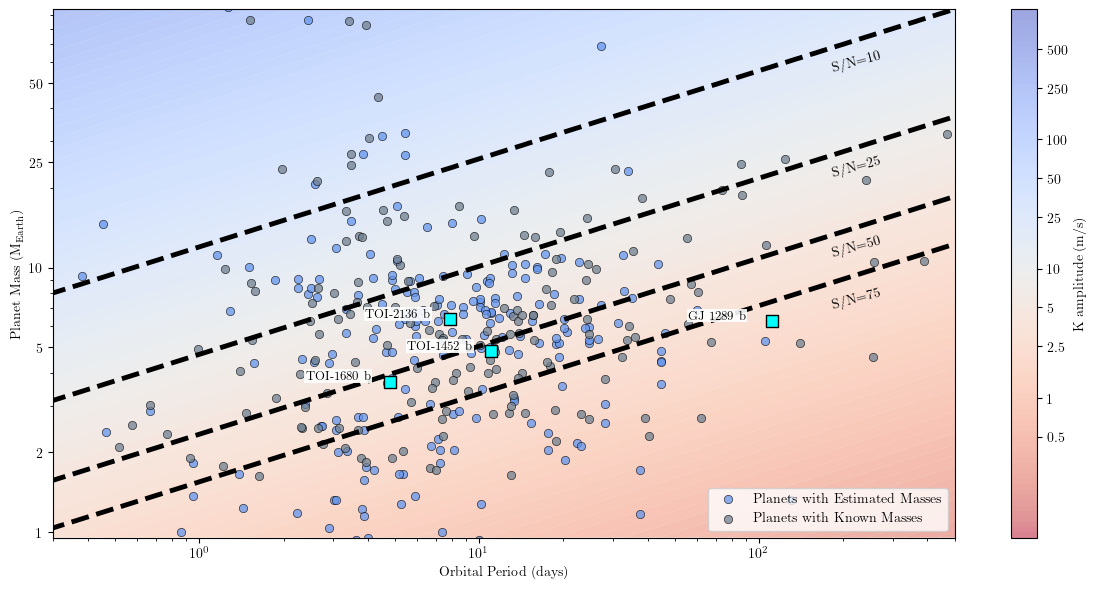

In [44]:

# Convert to numeric (mass may be in Jupiter masses, period in days — confirm if needed)
df_to_plot['mass'] = pd.to_numeric(df_to_plot['mass'], errors='coerce')
df_to_plot['pl_orbper'] = pd.to_numeric(df_to_plot['pl_orbper'], errors='coerce')
df_radius_mass['mass'] = pd.to_numeric(df_radius_mass['mass'], errors='coerce')
df_radius_mass['pl_orbper'] = pd.to_numeric(df_radius_mass['pl_orbper'], errors='coerce')

# Drop rows that failed numeric conversion
df_to_plot = df_to_plot.dropna(subset=['mass', 'pl_orbper'])

# Query: you might want to convert units (e.g. from Jupiter masses to Earth masses), but I'll leave as given


planets = ['TOI-2136 b','TOI-1452 b','GJ 1289 b','TOI-1680 b']
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})
def get_K(P_days, Mp_jupiter, Ms_solar):
    return 28.4 * ((P_days / 365.2422) ** (-1/3)) * Mp_jupiter * (Ms_solar ** (-2/3))

# Grid
P = np.logspace(-1, 4, 100)  # days
Mp = np.linspace(0.003, 0.8, 100)*317 # Jupiter masses
Ks = get_K(P[np.newaxis, :], Mp[:, np.newaxis]/317, 0.2)

# Create figure
fig, ax = plt.subplots(figsize=(12,6))
P_grid, Mp_grid = np.meshgrid(P, Mp)

# Make levels logarithmic but biased toward smaller values
num_levels = 100
levels = np.logspace(np.log10(Ks.min()), np.log10(Ks.max()), num_levels)

# Filled contour
cf = ax.contourf(
    P_grid,
    Mp_grid,
    Ks,
    levels=levels,
    cmap='coolwarm_r',
    norm=LogNorm(vmin=Ks.min(), vmax=Ks.max()),alpha=0.5, antialiased=True
)


ax.scatter(df_radius_mass['pl_orbper'], df_radius_mass['mass'],color = "cornflowerblue",#1E90FF",##1f77b4" ,   # muted blue
marker = "o",
alpha = 0.75,
edgecolor = "k",
linewidth = 0.5,label="Planets with Estimated Masses")#c="b",alpha=0.35)
ax.scatter(df_to_plot['pl_orbper'], df_to_plot['mass'],color = "#708090", #ff7f0e" ,   # muted orange
marker = "o",
alpha = 0.75,
edgecolor = "k",
linewidth = 0.5, label="Planets with Known Masses"
)#c="k",alpha=0.35,marker="s")

contour_levels = np.flip(dks*5)  # K values
P_grid, Mp_grid = np.meshgrid(P, Mp)
cs = ax.contour(
    P_grid,
    Mp_grid,
    Ks,
    levels=contour_levels,
    colors='k',
    linewidths=3.5,
    linestyles="--"
)

# Add individual planets
for name in planets:
    print(name)
    info = df_to_plot[df_to_plot['pl_name']==name]
    if info.empty: 
        print("here")
        info = df_radius_mass[df_radius_mass['pl_name']==name]
    ax.scatter(info['pl_orbper'], info['mass'], c='#00FFFF', s=75, zorder=5,marker="s",edgecolor="k")
    ax.text(
        info['pl_orbper']-5*info['pl_orbper']/10, info['mass'], name,
        color='black',
        fontsize=9,
        ha='left', va='bottom',
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=1),
        zorder=6
    )

ax.text(180, 55, "S/N=10", color='k', fontsize=10,rotation=15)
ax.text(180, 22, "S/N=25", color='k', fontsize=10,rotation=15)
ax.text(180, 11, "S/N=50", color='k', fontsize=10,rotation=15)
ax.text(180, 7, "S/N=75", color='k', fontsize=10,rotation=15)

# Axes
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Orbital Period (days)')
ax.set_ylabel('Planet Mass (M$_{\mathrm{Earth}}$)')
# ax.set_title('Sensitivity Plot')
ax.set_xlim(3e-1,5e2)
ax.set_ylim(0.003*317,0.3*317)
yticks = np.array([1,2,5,10,25,50])
ax.set_yticks(yticks)
ax.set_yticklabels([str(y) for y in yticks]) 

# Colorbar
# Example: set ticks manually
cbar = plt.colorbar(cf, ax=ax)

# Define specific K values for ticks
tick_values = [0.5,1,2.5,5,10,25,50,100,250,500]  # whatever makes sense for your K range

# Apply LogNorm correctly
cbar.set_ticks(tick_values)          # set tick locations
cbar.set_ticklabels([str(v) for v in tick_values])  # set labels

cbar.set_label('K amplitude (m/s)')

plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("sensitivity.pdf",dpi=300)
plt.show()

In [39]:
df_radius_mass[df_radius_mass['pl_name']=='TOI-1680 b']

,pl_name,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_rade,pl_radeerr1,pl_radeerr2,pl_orbper,st_spectype,sy_jmag,mass
19082,TOI-1680 b,NaN,NaN,NaN,1.466,0.063,-0.049,4.802634,M4.5+/-0.5,11.637,3.696287


In [40]:
df_to_plot[df_to_plot['pl_name']=='GJ 1289 b']

,pl_name,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_rade,pl_radeerr1,pl_radeerr2,pl_orbper,st_spectype,sy_jmag,mass
20993,GJ 1289 b,6.27,1.23,-1.25,NaN,NaN,NaN,111.74,M4.5 Ve,8.11,6.27


In [41]:
6.2/1.2

5.166666666666667

In [42]:
mask_mdwarf2 = df_md['st_spectype'].fillna("").str.startswith('M4')
ha = df_md[mask_mdwarf2].drop_duplicates(subset='pl_name', keep='first')
ha['mass'] = ha['pl_rade'].apply(mass_from_radius)
ha = ha[
    (ha['mass'] < 10) &
    (ha['mass'] > 2)
]
ha

,pl_name,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_rade,pl_radeerr1,pl_radeerr2,pl_orbper,st_spectype,sy_jmag,mass
1682,TOI-1743 b,NaN,NaN,NaN,1.830,0.110,-0.100,4.266046,M4 V,10.807000,5.855403
2943,K2-28 b,NaN,NaN,NaN,2.320,0.240,-0.240,2.260455,M4,11.695000,8.343403
2987,TOI-237 b,NaN,NaN,NaN,1.440,0.120,-0.120,5.436098,M4.5 V,11.740000,3.459254
3029,TOI-2096 b,NaN,NaN,NaN,1.243,0.077,-0.072,3.119063,M4,11.877000,2.006078
3686,TOI-715 b,NaN,NaN,NaN,1.550,0.064,-0.064,19.288004,M4,11.808000,4.569997
4765,TOI-4364 b,NaN,NaN,NaN,2.010,0.100,-0.080,5.424019,M4 V,9.952000,6.735505
4955,LHS 1140 b,5.60,0.19,-0.19,1.730,0.025,-0.025,24.737230,M4.5 V,9.612001,5.384327
8688,K2-384 e,NaN,NaN,NaN,1.345,0.139,-0.082,9.715043,M4 V,12.118000,2.686606
12040,Kepler-445 c,NaN,NaN,NaN,2.510,0.360,-0.360,4.871229,M4,13.542000,9.383540
12354,K2-384 d,NaN,NaN,NaN,1.392,0.118,-0.075,6.679582,M4 V,12.118000,3.051068
